# Выбор локации для скважины

**Описание проекта:**\
Добывающая компания «ГлавРосГосНефть» планирует расширить добычу нефти и выбирает регион для бурения новых скважин. В трёх регионах проведена геологоразведка, собраны данные о характеристиках скважин (качество нефти и объём запасов).

Цель проекта — построить модель машинного обучения, которая предскажет объём запасов нефти в новых скважинах, и поможет определить потенциально наиболее прибыльный регион для бурения.

**Цель:**\
Создание прогнозной модели машинного обучения:

- Разработка модели линейной регрессии для прогнозирования объёма запасов нефти в скважинах.
- Выбор 200 лучших точек в каждом регионе на основе предсказаний модели.
- Расчёт суммарной прибыли для каждого региона с учётом бюджета и рыночных условий.
- Оценка рисков методом Bootstrap и выбор региона с максимальной прибылью и вероятностью убытков < 2,5%.

**Ход исследования:**

- **Подготовка данных:** загрузка и изучение предоставленных данных о пробах нефти. Проверка структуры данных, наличия пропусков и аномалий.
- **Предобработка данных:** очистка от дубликатов и нерелевантных признаков в случае необходимости.
- **Анализ данных:** изучение взаимосвязей между признаками, оценка мультиколлинеарности.
- **Обучение модели:** Разделение данных на обучающую и валидационную выборки. Предварительная обработка признаков при необходимости. Построение модели линейной регрессии для предсказания объёма запасов (product) на основе признаков f0, f1, f2 для каждого региона. Оценка качества модели с помощью метрики RMSE.
- **Расчет потенциальной прибыли:** Выбор топ-200 точек с наибольшими предсказанными запасами. Определение суммарной прибыли для каждого региона с учётом: бюджета на разработку (10 млрд.руб.) и дохода в размере 450 тыс.руб./тыс.баррелей.
- **Оценка рисков:** генерация 1000 подвыборок (метод Bootstrap) для расчёта распределения прибыли. Расчёт средней прибыли, 95%-доверительного интервала и вероятности убытков.
- **Формирование рекомендаций:** анализ результатов, исключение регионов с вероятностью убытков ≥ 2,5%. Определение региона с максимальной средней прибылью на основе полученных данных.

**Описание данных:**\
`geo_data_0.csv`,`geo_data_1.csv`, `geo_data_2.csv`  — данные геологоразведки регионов.\
`f0`, `f1`, `f2` — признаки точек\
`product` - объем запасов в скважине (тыс.баррелей)

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from src.data_prepare import data_info, data_prepare
import src.visualization as visual

#Установка единого формата данных
pd.options.display.float_format = '{:,.3f}'.format
pd.options.mode.chained_assignment = None

RANDOM_STATE = 42
STATE = np.random.RandomState(12345)


## Загрузка и подготовка данных

In [2]:
geo_data_0 = pd.read_csv('data/geo_data_0.csv')
data_info(geo_data_0)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 100000 строк × 5 столбцов


,id,f0,f1,f2,product
0,txEyH,0.706,-0.498,1.221,105.280
1,2acmU,1.335,-0.340,4.365,73.038


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,count,mean,std,min,25%,50%,75%,max
f0,"100,000.000",0.500,0.872,-1.409,-0.073,0.502,1.074,2.362
f1,"100,000.000",0.250,0.504,-0.848,-0.201,0.250,0.701,1.344
f2,"100,000.000",2.503,3.248,-12.088,0.288,2.516,4.715,16.004
product,"100,000.000",92.500,44.289,0.000,56.498,91.850,128.564,185.364


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Явных дубликатов нет
Уникальность id
В поле с идентификатором есть дубликаты


Первичный общий анализ данных в таблице `geo_data_0` показал, что:

 - в данных нет пропусков 
 - типы данных соответствуют информации в таблице
 - средние значения и медианы близки, вероятно, в данных нет значительных выбросов и аномалий
 - в данных нет явных дубликатов, но есть дубликаты в поле `id`

In [3]:
geo_data_1 = pd.read_csv('data/geo_data_1.csv')
data_info(geo_data_1)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 100000 строк × 5 столбцов


,id,f0,f1,f2,product
0,kBEdx,-15.001,-8.276,-0.006,3.179
1,62mP7,14.272,-3.475,0.999,26.953


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,count,mean,std,min,25%,50%,75%,max
f0,"100,000.000",1.141,8.966,-31.610,-6.299,1.153,8.621,29.422
f1,"100,000.000",-4.797,5.120,-26.359,-8.268,-4.813,-1.333,18.734
f2,"100,000.000",2.495,1.704,-0.018,1.000,2.011,4.000,5.020
product,"100,000.000",68.825,45.944,0.000,26.953,57.086,107.813,137.945


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Явных дубликатов нет
Уникальность id
В поле с идентификатором есть дубликаты


Первичный общий анализ данных в таблице `geo_data_1` показал, что:

 - в данных нет пропусков 
 - типы данных соответствуют информации в таблице
 - средние значения и медианы близки, вероятно, в данных нет значительных выбросов и аномалий
 - значения в полях `f0` и `f1` имеют больший диапазон, чем для региона geo_0. При этом объем запасов в среднем ниже.
 - в данных нет явных дубликатов, но есть дубликаты в поле `id`

In [4]:
geo_data_2 = pd.read_csv('data/geo_data_2.csv')
data_info(geo_data_2)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 100000 строк × 5 столбцов


,id,f0,f1,f2,product
0,fwXo0,-1.147,0.963,-0.829,27.759
1,WJtFt,0.263,0.270,-2.530,56.070


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,count,mean,std,min,25%,50%,75%,max
f0,"100,000.000",0.002,1.732,-8.760,-1.162,0.009,1.159,7.238
f1,"100,000.000",-0.002,1.730,-7.084,-1.175,-0.009,1.164,7.845
f2,"100,000.000",2.495,3.473,-11.970,0.130,2.484,4.859,16.739
product,"100,000.000",95.000,44.750,0.000,59.450,94.926,130.595,190.030


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Явных дубликатов нет
Уникальность id
В поле с идентификатором есть дубликаты


Первичный общий анализ данных в таблице `geo_data_2` показал, что:

 - в данных нет пропусков 
 - типы данных соответствуют информации в таблице
 - средние значения и медианы близки, вероятно, в данных нет значительных выбросов и аномалий
 - в данных нет явных дубликатов, но есть дубликаты в поле `id`

<b>Вывод по разделу "Загрузка данных"</b>

- Во всех таблицах содержится 100000 наблюдений.
- Данные в таблицах соответствуют описанию. Типы данных корректны. Пропусков нет.
- Числовые данные имеют разные диапазоны значений, для применения линейной модели потребуется их масштабирование.
- В данных нет явных дубликатов, но есть дубликаты в поле с идентификатором скважины. Подробнее рассмотрим неявные дубли в разделе с предобработкой данных.

## Предобработка данных

Среди уникальных идентификаторов скважин есть дубликаты, посмотрим на них внимательнее.

In [5]:
for id in geo_data_0.loc[geo_data_0.duplicated(subset='id', keep=False), 'id'].unique():
        display(geo_data_0.loc[geo_data_0['id'] == id])


,id,f0,f1,f2,product
931,HZww2,0.755,0.369,1.863,30.682
7530,HZww2,1.061,-0.374,10.430,158.829


,id,f0,f1,f2,product
1364,bxg6G,0.412,0.857,-3.653,73.604
41724,bxg6G,-0.824,0.546,3.630,93.008


,id,f0,f1,f2,product
1949,QcMuo,0.507,-0.324,-2.216,75.497
63593,QcMuo,0.636,-0.473,0.863,64.579


,id,f0,f1,f2,product
3389,A5aEY,-0.040,0.157,0.210,89.249
51970,A5aEY,-0.180,0.936,-2.095,33.020


,id,f0,f1,f2,product
16633,fiKDv,0.157,1.028,5.586,95.818
90815,fiKDv,0.050,0.841,6.395,137.347


,id,f0,f1,f2,product
21426,Tdehs,0.829,0.299,-0.050,96.035
75715,Tdehs,0.112,0.430,3.219,60.964


,id,f0,f1,f2,product
42529,AGS9W,1.455,-0.480,0.683,126.371
69163,AGS9W,-0.934,0.116,-3.656,19.230


,id,f0,f1,f2,product
60140,TtcGQ,0.569,-0.105,6.440,85.350
92341,TtcGQ,0.111,1.023,0.911,101.318


,id,f0,f1,f2,product
64022,74z30,0.741,0.459,5.153,140.771
66136,74z30,1.085,-0.312,6.991,127.643


,id,f0,f1,f2,product
89582,bsk9y,0.399,-0.400,10.122,163.433
97785,bsk9y,0.378,0.006,0.161,160.637


Можно обратить внимание, что данные значительно отличаются друг от друга, несмотря на дубли в поле `id`. Вероятно, произошла ошибка при маркировке скважин. Установить корректный `id` не представляется возможным, но это и не требуется на текущем этапе, т.к. решение по региону принимается без привязки к конкретным точкам. Оставим дубли без изменений.

In [6]:
for id in geo_data_1.loc[geo_data_1.duplicated(subset='id', keep=False), 'id'].unique():
        display(geo_data_1.loc[geo_data_1['id'] == id])


,id,f0,f1,f2,product
1305,LHZR0,11.171,-1.945,3.003,80.860
41906,LHZR0,-8.990,-4.287,2.009,57.086


,id,f0,f1,f2,product
2721,bfPNe,-9.494,-5.464,4.006,110.992
82178,bfPNe,-6.203,-4.820,2.995,84.039


,id,f0,f1,f2,product
5849,5ltQ6,-3.435,-12.296,2.000,57.086
84461,5ltQ6,18.214,2.192,3.994,107.813


,id,f0,f1,f2,product
47591,wt4Uk,-9.091,-8.109,-0.002,3.179
82873,wt4Uk,10.260,-9.376,4.994,134.766


Дубли в поле `id` оставим без изменений по той же логике, что в предыдущем случае.

In [7]:
for id in geo_data_2.loc[geo_data_2.duplicated(subset='id', keep=False), 'id'].unique():
        display(geo_data_2.loc[geo_data_2['id'] == id])


,id,f0,f1,f2,product
11449,VF7Jo,2.123,-0.858,5.746,181.717
49564,VF7Jo,-0.883,0.561,0.724,136.233


,id,f0,f1,f2,product
28039,xCHr8,1.633,0.368,-2.378,6.121
43233,xCHr8,-0.847,2.102,5.597,184.389


,id,f0,f1,f2,product
44378,Vcm5J,-1.229,-2.439,1.223,137.968
95090,Vcm5J,2.588,1.987,2.482,92.328


,id,f0,f1,f2,product
45404,KUPhW,0.232,-1.699,4.991,11.716
55967,KUPhW,1.211,3.176,5.544,132.832


Дубли в поле `id` оставим без изменений.

<b>Вывод по разделу "Предобработка данных"</b>

В ходе предобработки были обнаружены дубликаты в поле `id`. Было решено оставить эти значения без изменений по следующим причинам:
- измерения у скважин с одинаковым `id` значительно отличаются. Вероятно, имеет место ошибка при маркировке.
- восстановить корректный `id` проблематично
- в текущем исследовании точное идентифицирование скважин не требуется

## Анализ данных

1. Первичный анализ общей информации о данных показал, что медиана и среднее близки, что может косвенно свидетельствовать о том, что в данных нет значительных выбросов и аномалий. В любом случае у нас нет детальной информации о специфике данных, поэтому выбросы и аномалии даже в случае их наличия логичнее будет оставить без изменений.
2. Особенность задачи предполагает использование линейной модели, поэтому важно исключить мультиколлинеарность данных. Чтобы корректно выбрать коэффициент корреляции предварительно построим графики распределения признаков.

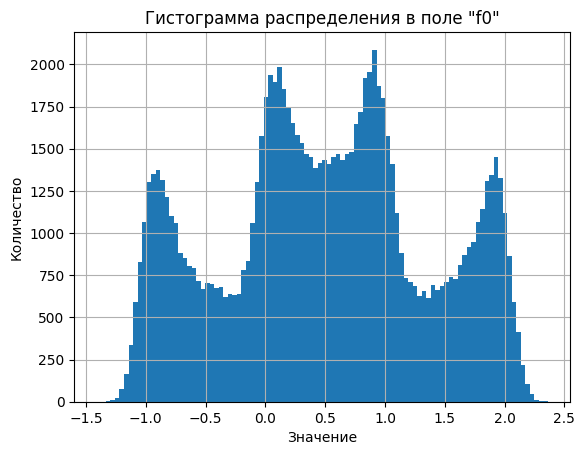

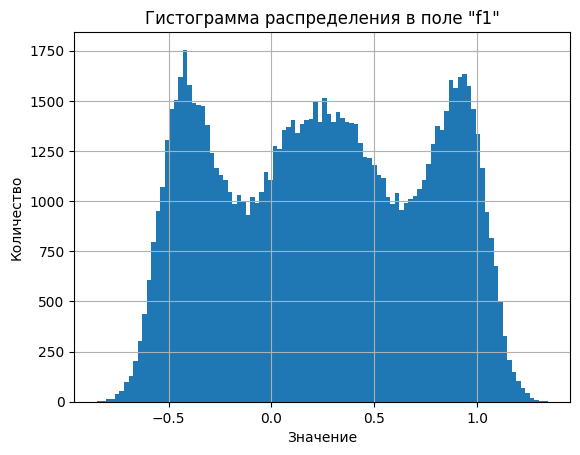

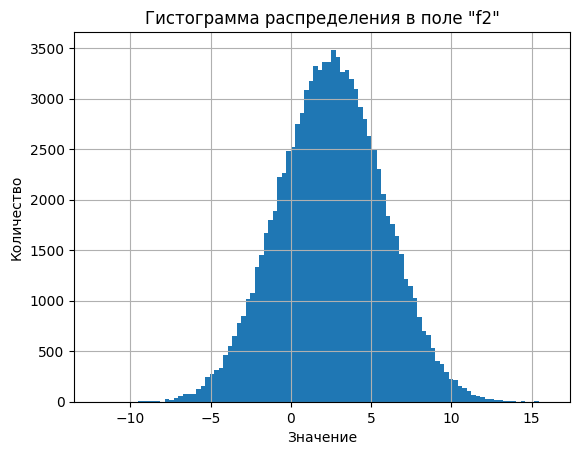

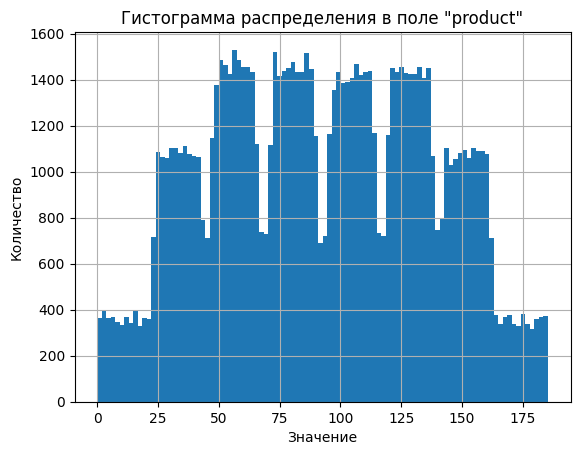

In [8]:
visual.numeric_graph(geo_data_0)


Данные симметрично распределены вокруг среднего, однако, у признаков `f0` и `f1` не соблюдена колокообразная форма. Явно видно, что признаки распределены ненормально. В дальнейшем при проверке на мультиколлинеарность используем для расчета коэффициент Спирмена.

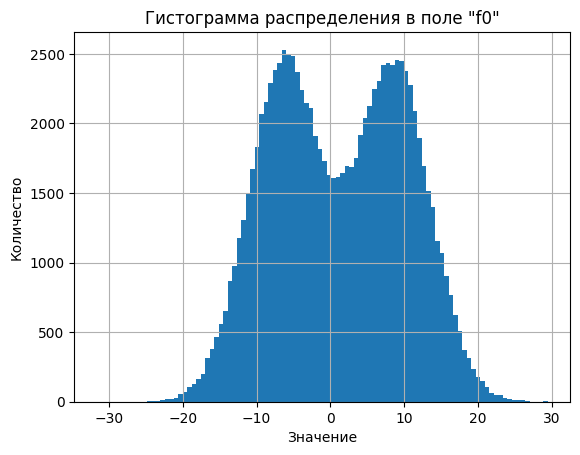

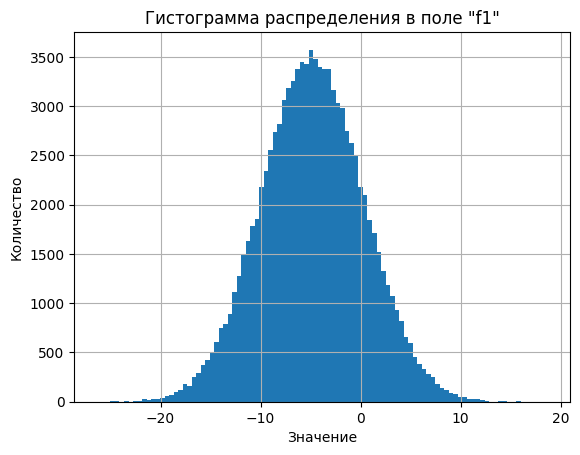

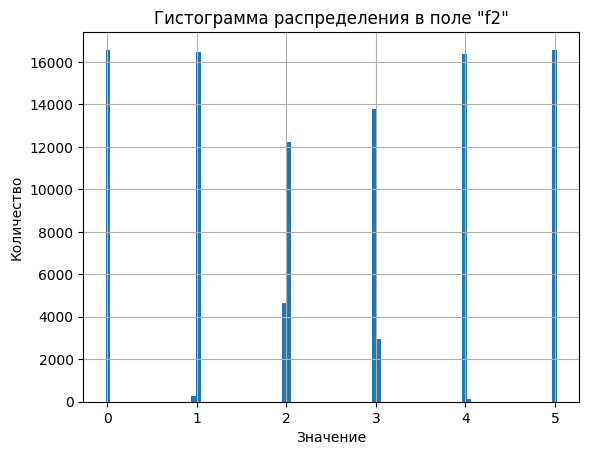

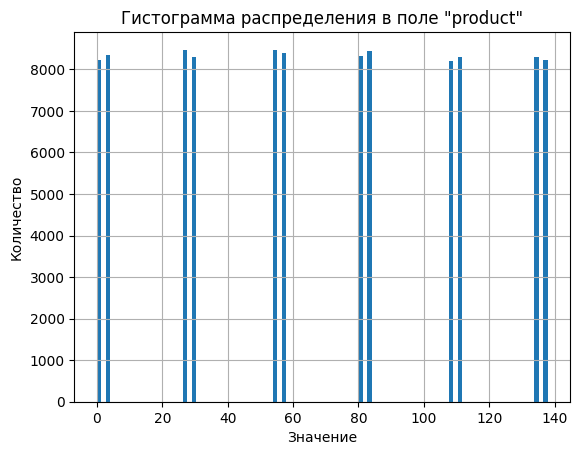

In [9]:
visual.numeric_graph(geo_data_1)


Основываясь на форме графиков распределений можно сделать вывод, что в данном случае признаки также распределены ненормально.

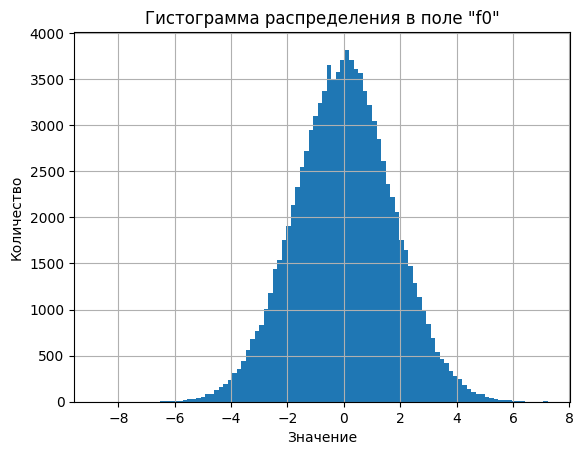

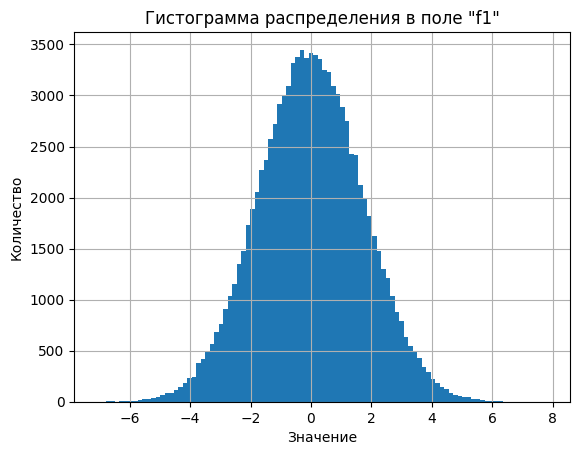

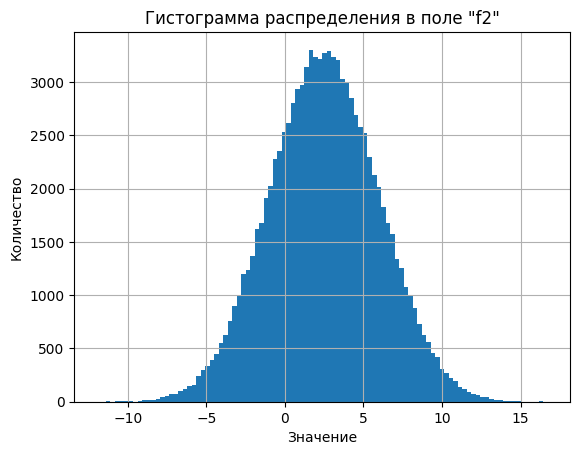

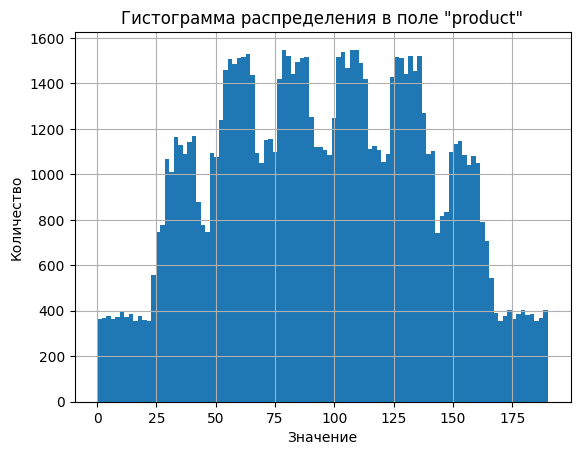

In [10]:
visual.numeric_graph(geo_data_2)


В поле `f1` распределение признака не симметрично вокруг среднего, т.е. признак распределен ненормально. В остальных случаях визуально распределение похоже на нормальное. Учитывая, "ненормальность" признака `f1` используем также коэффициент Спирмена.

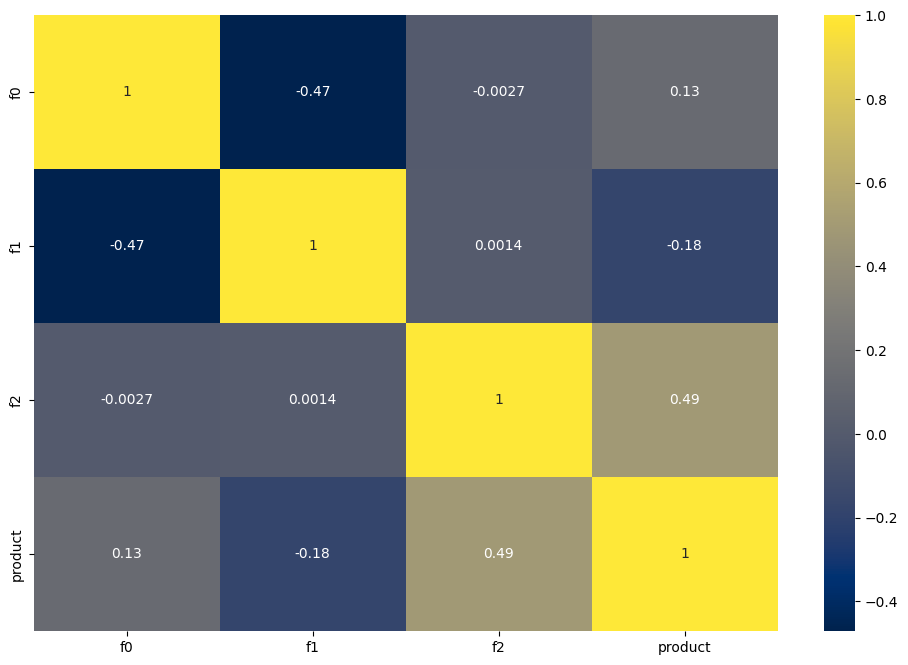

In [11]:
visual.corr_matrix(geo_data_0, method='spearman')


Согласно тепловой карте, самая сильная прямая связь с целевым признаком у признака `f2` (0.49). По шкале Чеддока такая корреляция считается умеренной. О мультиколлинеарности же, как правило, говорят при значении коэффициента от 0.9 по модулю. В наших данных таких значений нет.

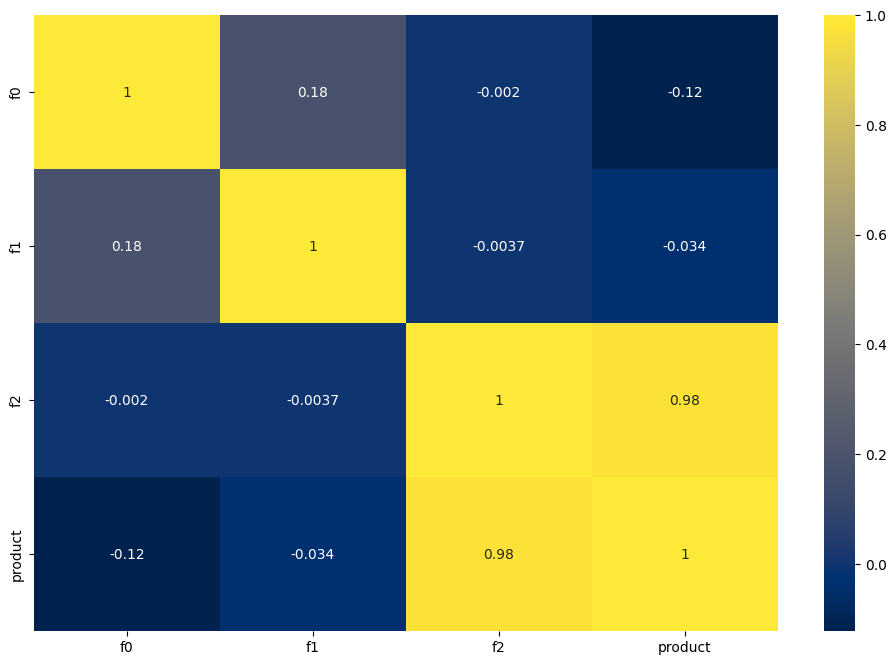

In [12]:
visual.corr_matrix(geo_data_1, method='spearman')


Поле `f2` имеет очень высокую корреляцию с целевым признаком (0.98). Можно было бы предположить, что такая высокая корреляция свидетельствует об утечке данных. Однако, нам неизвестна природа данных и гарантировать этого мы не можем. К тому же, этот признак для другого региона уже не имеет такой высокой корреляции с объемом запасом. Если считать, что признаки для всех регионов одинаковы, то в данном случае утечки быть не может. Оставим признак в модели.

Мультиколлинеарности между признаками нет.

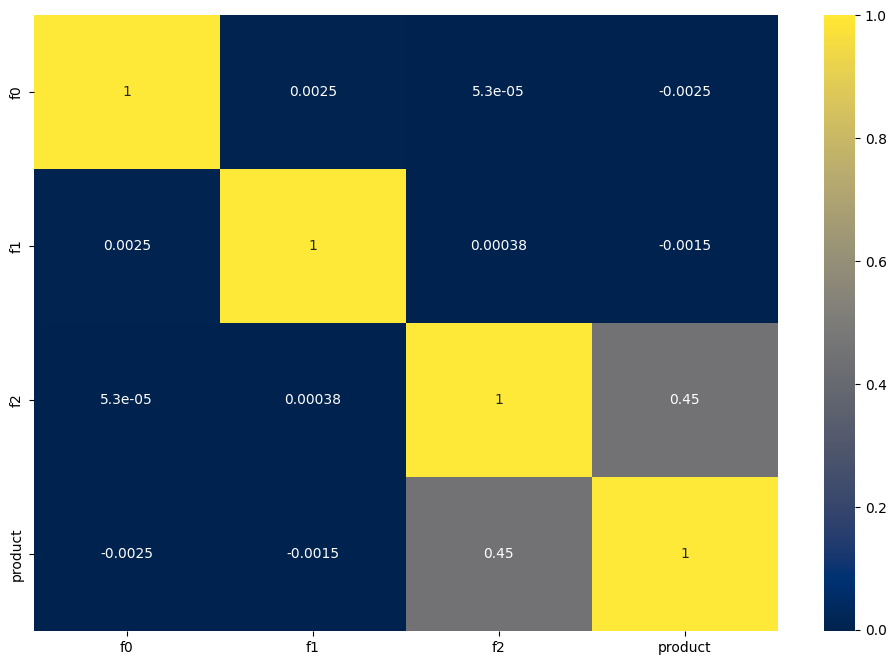

In [13]:
visual.corr_matrix(geo_data_2, method='spearman')


Согласно тепловой карте, самая сильная прямая связь (умеренная корреляция) с целевым признаком у признака `f2` (0.45). Мультиколлинеарности между признаками нет.

Построим матрицу диаграмм рассеяния,чтобы оценить связь количественных признаков с целевым.

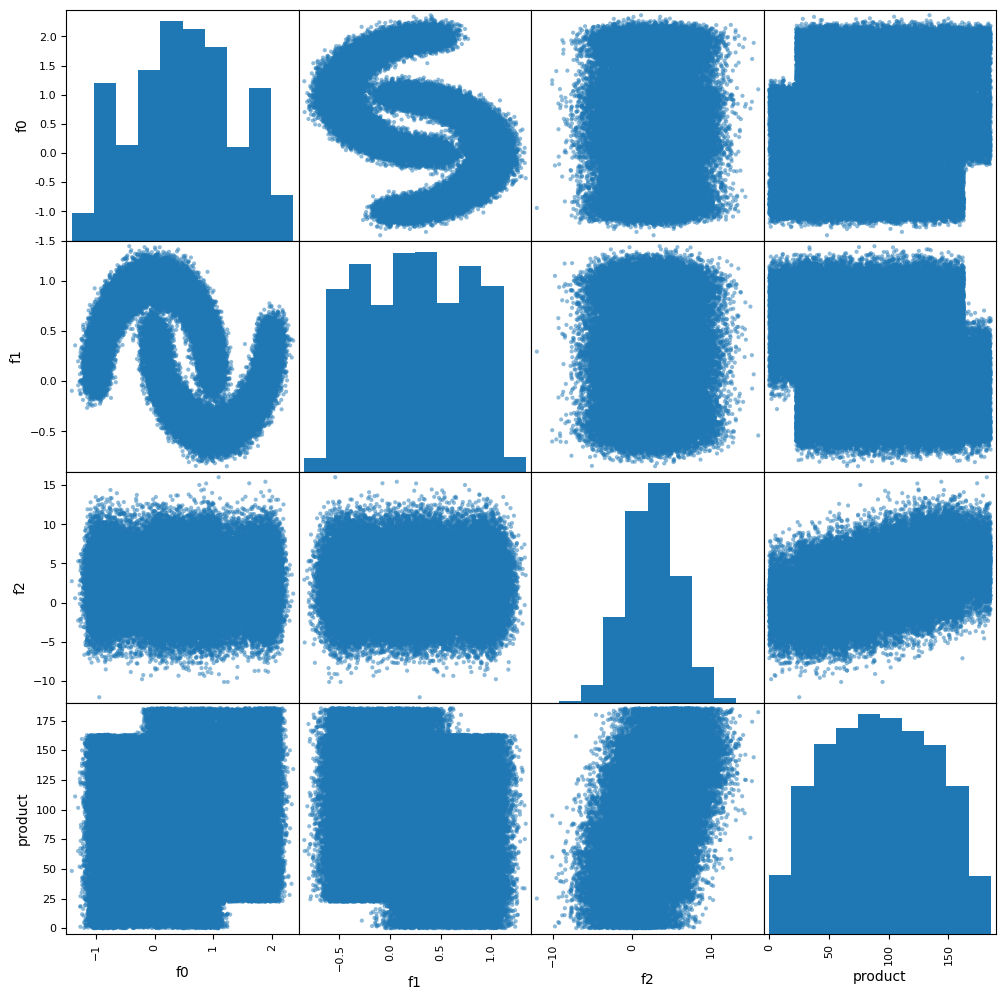

In [14]:
pd.plotting.scatter_matrix((geo_data_0), figsize=(12, 12));


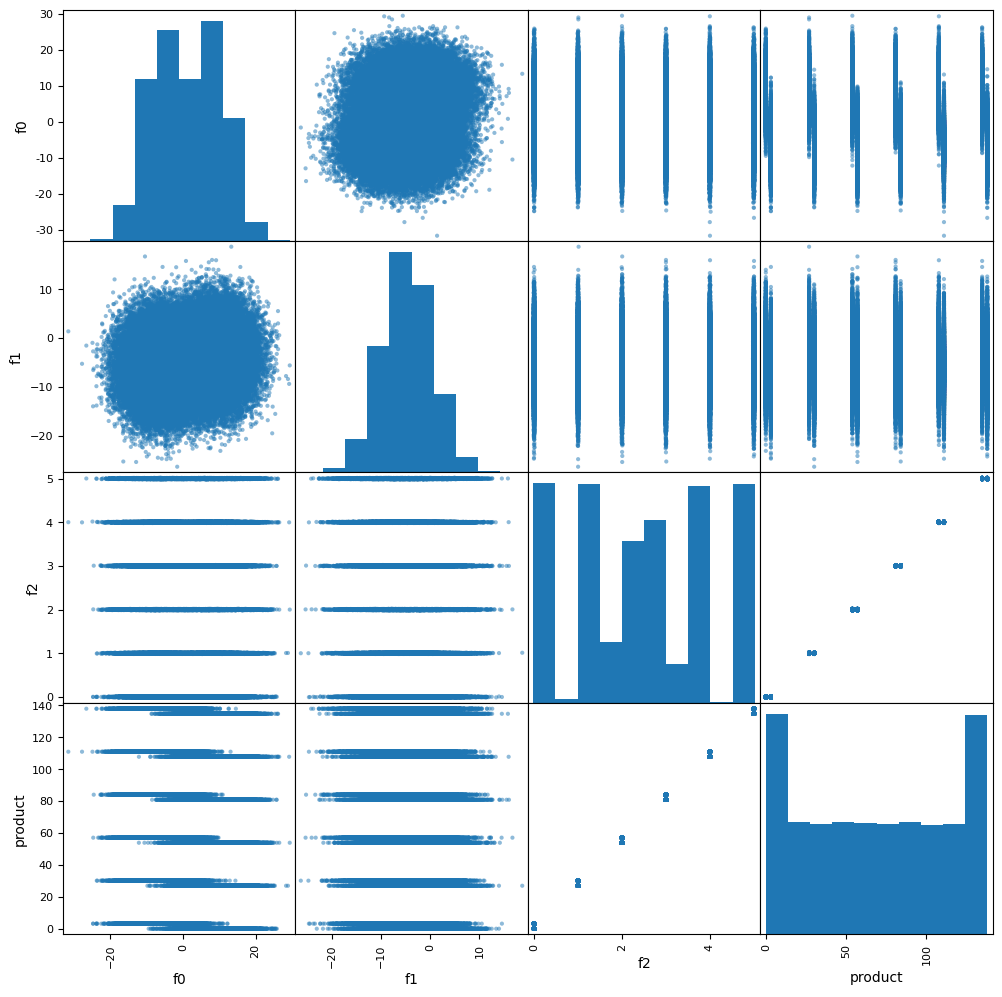

In [15]:
pd.plotting.scatter_matrix((geo_data_1), figsize=(12, 12));


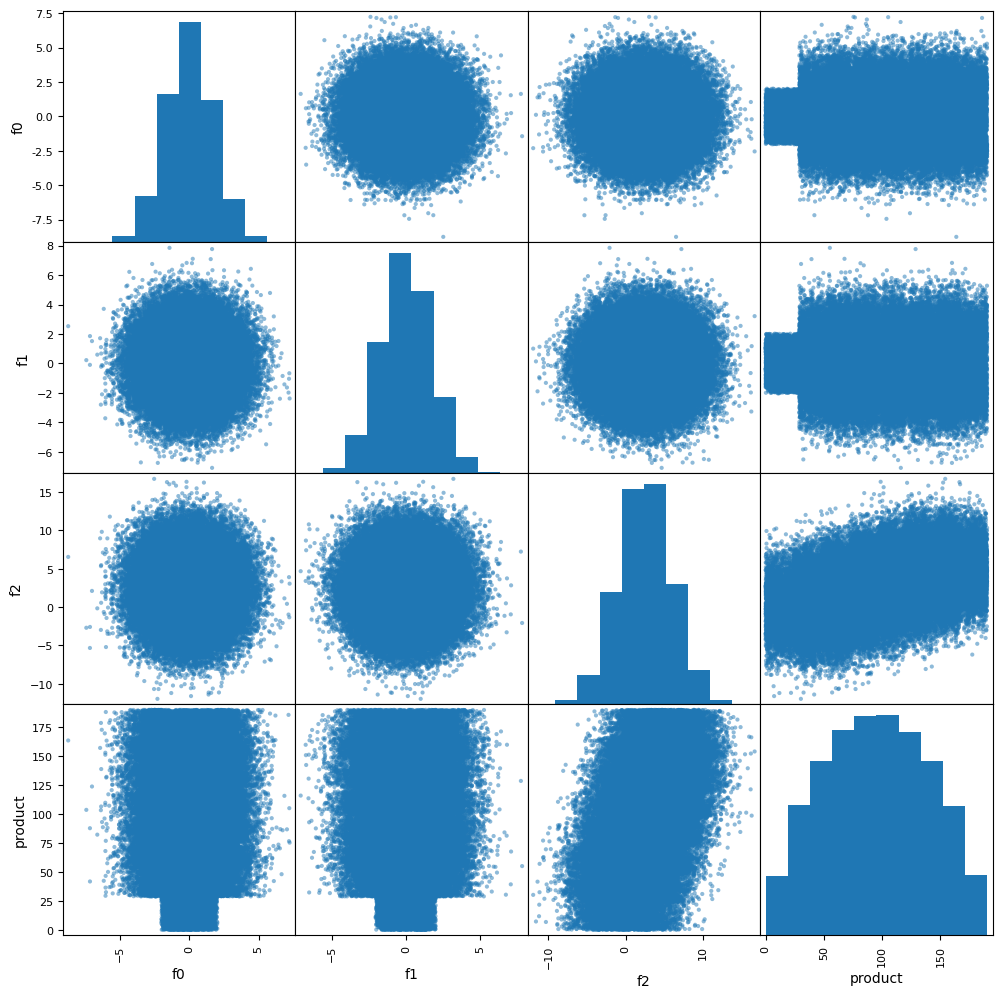

In [16]:
pd.plotting.scatter_matrix((geo_data_2), figsize=(12, 12));


Как видно из диаграмм рассеяния линейная связь наблюдается у целевого признака и `f2`. Однако, в случае региона geo_1 можно говорить о склонности к кластеризации, что уже по сути не является линейной связью. Признаки `f0`и `f1` связаны с целевым нелинейно.

<b>Вывод по разделу "Анализ данных"</b>

- Данные распределены ненормально.
- Мультиколлинеарность признаков не обнаружена.
- Обнаружена выскокая корреляция между целевым признаком и `f2`. В связи с тем, что природа данных неизвестна, а также нет явно выраженной связи между этими признаками для других регионов, принято решение оставить признак при моделировании.
- Признаки `f0` и `f1` связаны с целевым нелиненйо. Признак `f2` в случае двух регионов имеет линейную связь с целевым признаком, однако, в случае региона `geo_1` имеет тенденцию к кластеризации. Это может привести к невысокому качеству при применении линейной модели.

## Обучение и проверка модели

Перед обучением применим к каждому набору данных функцию data_prepare, которая выполняет следующие этапы предобработки:
- удаляет ненужную колонку из предикторов модели (`id`) 
- выделяет таргет в отдельный датасет
- разделяет выборки на тренировочую и валидационную в пропорции 75/25
- применяет масштабирование к признакам 

### Модель для региона `geo_data_0`

In [17]:
X_train_geo_0, X_val_geo_0, y_train_geo_0, y_val_geo_0 = data_prepare(geo_data_0, RANDOM_STATE)


,f0,f1,f2
0,1.275,-0.800,-0.397
1,-1.601,0.235,-2.169


,f0,f1,f2
0,0.114,-1.605,-0.120
1,0.274,-1.418,-1.187


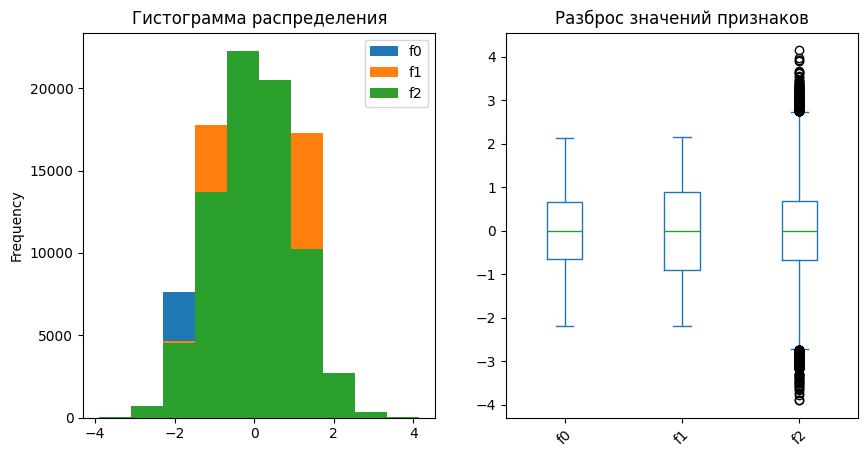

In [18]:
visual.check_scaler(X_train_geo_0)


Диапазон значений после масштабирования лежит в промежутке [-4, 4]. Видим, что в поле `f2` присутствует большое количество выбросов. на предыдущем этапе мы решили не обрабатывать выбросы, т.к. нам неизвестна природа данных и, возможно, в данном случае эти значения важны. Т.к. в качестве метрики мы используем RMSE, которая подвержена влиянию выбросов мы сможем учесть эти особенности датасета.

Приступаем к обучению модели.

In [19]:
model_geo_0  = LinearRegression()

model_geo_0.fit(X_train_geo_0, y_train_geo_0)
predictions_geo_0 = model_geo_0.predict(X_val_geo_0)


In [20]:
print('Cредний запас предсказанного сырья:', predictions_geo_0.mean())
print('RMSE модели:', np.sqrt(mean_squared_error(y_val_geo_0, predictions_geo_0)))


Cредний запас предсказанного сырья: 92.39879990657768
RMSE модели: 37.75660035026169


В среднем модель ошибается на 37.7 тыс.баррелей. Предсказанный средний запас сырья (92.4) близок к указанному среднему по всем скважинам (92.5), которое мы получили на этапе первичного анализа данных.

### Модель для региона `geo_data_1`

In [21]:
X_train_geo_1, X_val_geo_1, y_train_geo_1, y_val_geo_1 = data_prepare(geo_data_1, RANDOM_STATE)


,f0,f1,f2
0,0.911,0.064,-0.291
1,1.641,1.321,1.464


,f0,f1,f2
0,0.552,0.956,-1.463
1,1.711,1.469,-0.295


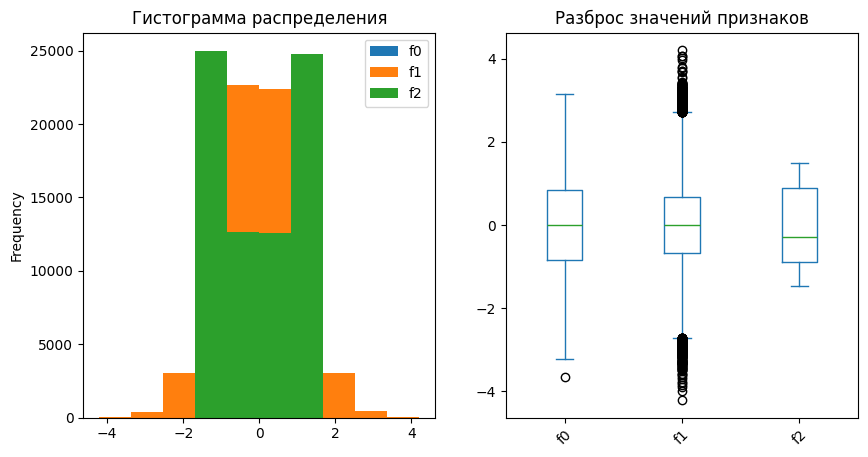

In [22]:
visual.check_scaler(X_train_geo_1)


Диапазон значений после масштабирования также лежит в промежутке [-4, 4]. Для региона `geo_1` выбросы присутствуеют в поле `f1`.

In [23]:
model_geo_1  = LinearRegression()

model_geo_1.fit(X_train_geo_1, y_train_geo_1)
predictions_geo_1 = model_geo_1.predict(X_val_geo_1)


In [24]:
print('Cредний запас предсказанного сырья:', predictions_geo_1.mean())
print('RMSE модели:', np.sqrt(mean_squared_error(y_val_geo_1, predictions_geo_1)))


Cредний запас предсказанного сырья: 68.7128780391376
RMSE модели: 0.8902801001028836


RMSE на этой модели значительно меньше - 0.89 тыс.баррелей. Предсказанный средний запас сырья (68.7) близок к указанному среднему по всем скважинам (68.8), которое мы получили на этапе первичного анализа данных.

### Модель для региона `geo_data_2`

In [25]:
X_train_geo_2, X_val_geo_2, y_train_geo_2, y_val_geo_2 = data_prepare(geo_data_2, RANDOM_STATE)


,f0,f1,f2
0,-0.344,-1.338,0.818
1,-0.400,0.994,-1.103


,f0,f1,f2
0,1.218,-0.967,0.175
1,0.423,0.435,0.336


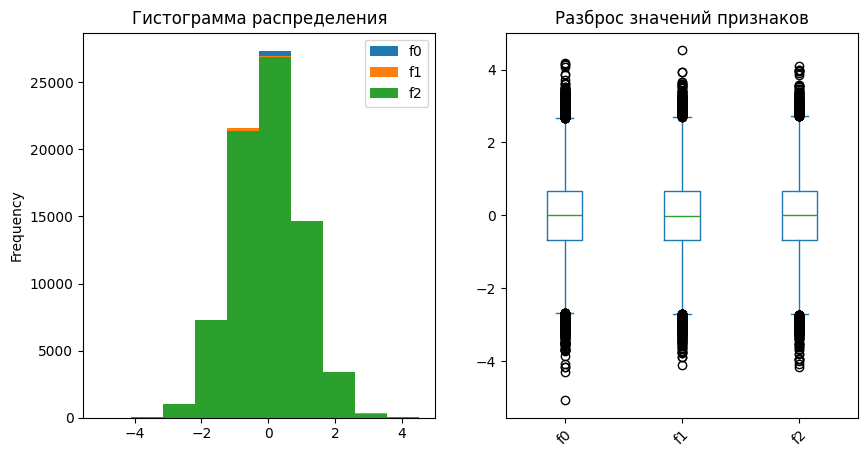

In [26]:
visual.check_scaler(X_train_geo_2)


Диапазон значений после масштабирования также лежит в промежутке [-4, 4]. Для региона `geo_2` выбросы присутствуеют во всех трех признаках.

In [27]:
model_geo_2  = LinearRegression()

model_geo_2.fit(X_train_geo_2, y_train_geo_2)
predictions_geo_2 = model_geo_2.predict(X_val_geo_2)


In [28]:
print('Cредний запас предсказанного сырья:', predictions_geo_2.mean())
print('RMSE модели:', np.sqrt(mean_squared_error(y_val_geo_2, predictions_geo_2)))


Cредний запас предсказанного сырья: 94.77102387765939
RMSE модели: 40.14587231134218


RMSE на этой модели близок самый высокий, в среднем модель ошибается на 40 тыс. баррелей. Предсказанный средний запас сырья (94.8) близок к указанному среднему по всем скважинам (95), которое мы получили на этапе первичного анализа данных.

<b>Вывод по разделу "Обучение и проверка модели"</b>


Получены следующие результаты:

| Метрика|   geo_0   |   geo_1   |   geo_2   |
| -------| ----------| ----------|-----------|
| RMSE   |   37.757  |   0.89    |   40.15   |
| Запасы |   92.40   |   68.71   |   94.77   |


- Самая низкая ошибка RMSE у региона `geo_1` - 0.89 тыс.баррелей, модель хорошо предсказывает объем сырья в этом регионе. Следовательно, риск сделать ошибочный вывод минимален. В двух других регионах ошибка значительно выше: 37 и 40 тыс.баррелей.
- Самый высокий запас предсказанного сырья в регионе `geo_2`- 94.7 тыс.баррелей . В этом же регионе самая высокая ошибка предсказаний (40 тыс.баррелей). Выбирать данный регион на основании предсказаний может быть рискованно. Самый низкий запас в регионе `geo_1` - 68.7 тыс.баррелей, однако, это предсказание наиболее точное согласно метрике RMSE.

## Подготовка к расчёту прибыли

Сохраним необходимые данные для расчетов.

In [29]:
OIL_WELL_COUNT = 500
OIL_WELL_BEST_COUNT = 200
DEVELOP_BUDGET = 10000000000
PRICE_FOR_BARREL = 450000
MAX_PROBABILITY_OF_LOSS = 0.025


Рассчитаем точку безубыточноти проекта. Точка безубыточности — это минимальный объём добычи, при котором доходы покрывают затраты (бюджет на разработку/доход с единицы (тыс.баррелей). Нам известно, что в разработку берется 200 лучших скважин. Расчитаем минимальный необходимый объем запасов для окупаемости расходов в расчете на одну скважину.

In [30]:
BREAKEVEN_POINT = DEVELOP_BUDGET/PRICE_FOR_BARREL/OIL_WELL_BEST_COUNT
print(f'Точка безубыточности: {BREAKEVEN_POINT:.2f} тыс.баррелей со скважины')


Точка безубыточности: 111.11 тыс.баррелей со скважины


<b>Вывод по разделу "Подготовка к расчёту прибыли"</b>

Объём запасов в каждой скважине должен быть не менее 111 тыс.баррелей для окупаемости расходов на разработку региона. Средний предсказанный объем запасов в каждом регионе по всем скважинам ниже требуемого. 

| Рагион | Ср.запасы |  Разница  | 
| -------| ----------| ----------|
| geo_0  |   92.40   |   -18.71  |  
| geo_1  |   68.71   |   - 42.4  | 
| geo_2  |   94.77   |   -16.4   |  

Ближе всего к целевому значению регион `geo_2`. Однако, средний объем запасов по региону может некорректно характеризовать 200 лучших скважин в регионе. При расчете потенциальной прибыли выделим в каждом регионе 200 скважин. наибольшим объёмом. 

## Расчёт прибыли и рисков 

Подготовим функцию для подсчёта прибыли: необходимо отобрать 200 скважин с лучшими предсказаниями и расcчитать выручку, основываясь на поле `product`. Чтобы получить прибыль вычтем из выручки бюджет на разработку месторождения. Для удобства представим прибыль в млн.руб.

In [31]:
def profit(target, predictions, amount=OIL_WELL_BEST_COUNT, price=PRICE_FOR_BARREL, budget=DEVELOP_BUDGET):
    df=pd.DataFrame({'product': target,
                     'prediction': predictions})
    best_200 = df.sort_values(by='prediction', ascending=False)[:amount]
    revenue = best_200['product'].sum() * price
    profit = (revenue - budget)/1000000
    return profit


Для удобства расчетов по каждому региону подготовим функцию для расчета прибыли с применением метода Bootstrap, доверительного интервала и убытков. Под убытками понимаем результаты с отрицательной прибылью. Чтобы рассчитать риск убытков посчитаем долю количество выборок с отрицательной прибылью от общего числа выборок (1000).

In [32]:
def profit_and_losses(target, predictions, count=OIL_WELL_COUNT, samples=1000, state=STATE):
    profits = []
    
    for i in range(samples):
        target_subsample = target.reset_index(drop=True).sample(n=count, replace=True, random_state=state)
        probabilities_subsample = predictions[target_subsample.index]
        profits.append(profit(target_subsample, probabilities_subsample))
        
    profits = pd.Series(profits)
    mean_profit = profits.mean()
    
    lower = profits.quantile(0.025)
    upper = profits.quantile(0.975)
    
    risk_of_loss = len(profits[profits<0])/samples
    
    print(f'Средняя прибыль: {mean_profit:.2f} млн.руб.')
    print(f'С вероятностью 95% прибыль в регионе составит от {lower:.2f} млн.руб. до {upper:.2f} млн.руб.')
    print(f'Риск убытков составляет: {risk_of_loss:.2%}')
    return profits, mean_profit, risk_of_loss


Посчитаем среднюю прибыль и риск убытков для каждого региона

In [33]:
# Регион `geo_0`
profits_0, mean_profit_0, risk_of_loss_0 = profit_and_losses(y_val_geo_0, predictions_geo_0)


Средняя прибыль: 406.28 млн.руб.
С вероятностью 95% прибыль в регионе составит от -117.74 млн.руб. до 911.74 млн.руб.
Риск убытков составляет: 6.70%


In [34]:
# Регион `geo_1`
profits_1, mean_profit_1, risk_of_loss_1 = profit_and_losses(y_val_geo_1, predictions_geo_1)


Средняя прибыль: 441.50 млн.руб.
С вероятностью 95% прибыль в регионе составит от 35.73 млн.руб. до 828.01 млн.руб.
Риск убытков составляет: 1.60%


In [35]:
# Регион `geo_2`
profits_2, mean_profit_2, risk_of_loss_2 = profit_and_losses(y_val_geo_2, predictions_geo_2)


Средняя прибыль: 385.21 млн.руб.
С вероятностью 95% прибыль в регионе составит от -164.79 млн.руб. до 888.21 млн.руб.
Риск убытков составляет: 7.80%


Для наглядности визуализируем финальные результаты. Построим графики "ящик с усами" по расчетной прибыли для каждого региона и график для сравнения средней прибыли и рисков по каждому региону. 

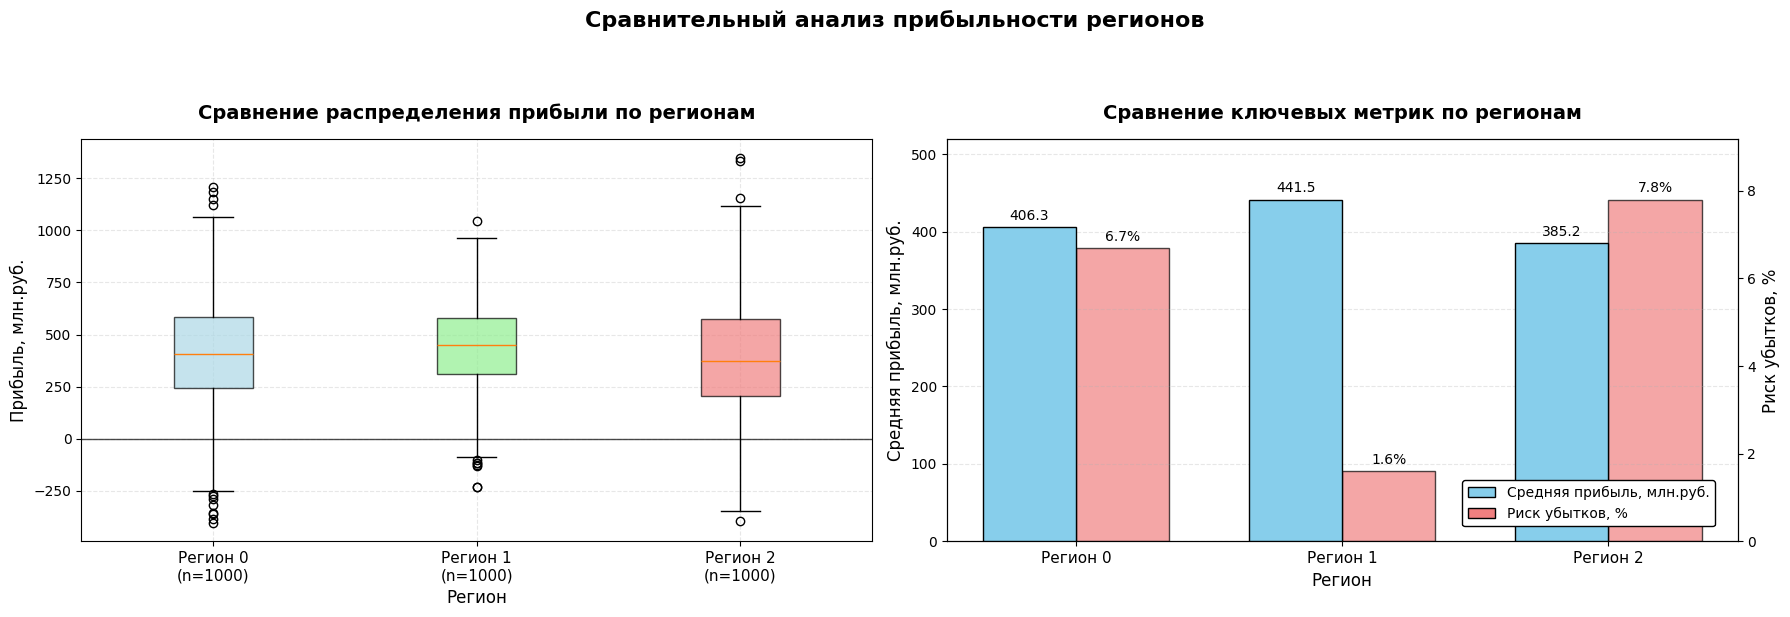

In [36]:
regions_data = [
    (profits_0, mean_profit_0, risk_of_loss_0),
    (profits_1, mean_profit_1, risk_of_loss_1),
    (profits_2, mean_profit_2, risk_of_loss_2)
]

region_names = ['Регион 0', 'Регион 1', 'Регион 2']

visual.compare_regions_profits(regions_data, region_names)


Регион `geo_0` — компромиссный вариант: средняя прибыль высокая (~406,3 млн руб.), но и риск убытков досттаочно высок (~6,7%). Регион `geo_2` выглядит наименее привлекательным: самая низкая средняя прибыль (~385,2 млн руб.) при максимальном риске (~7,8%). Графики “ящик с усами” показывают наличие выбросов и отрицательных сценариев по всем регионам (больше всего по региону `geo_0`), поэтому при принятии решения следует опираться не только на потенциальную прибыль, но и на вероятность уйти в минус.

По этим критериям видно, что регион `geo_1` выглядит наиболее предпочтительным для разработки: у него самая высокая средняя прибыль (~441,5 млн руб.) при минимальном риске убытков (~1,6%). К тому же согласно ТЗ, заказчику не подходят регионы с вероятностью убытков выше 2,5%.

<b>Вывод по разделу "Расчёт прибыли и рисков "</b>

По результатам расчета прибыли и риска убытков с применением метода Bootstrap, можно рекомендовать к разработке регион `geo_1`. Данный регион имеет самое высокое значение средней прибыли млн.рублей и самый низкий риск убытков. Остальные регионы не проходят по критерию отсечения: риск убытков не должен превышать 2,5%.

## Итоговые выводы

В ходе проекта разработаны модели линейной регрессии для прогнозирования объёмов добычи нефти в трёх регионах (`geo_0`, `geo_1`, `geo_2`). На основании анализа данных, обучения моделей и расчёта экономических показателей **рекомендуется к разработке регион `geo_1`**, т.к. он демонстрирует наилучшее сочетание точности прогноза (RMSE=0.87), прибыльности и приемлемого уровня риска (ниже порога отсечения в 2,5%).

В ходе проекта были выполнены следующие этапы:
1. Предобработка данных:
- Обнаружены дубликаты в поле id, оставленные без изменений из-за невозможности корректного восстановления и отсутствия необходимости использования этих данных при обучении.

2. Анализ данных:
- Выявлено, что данные имеют ненормальное распредление.
- Выявлена нелинейная связь целевого признака с `f0`, `f1` и кластеризация для `f2` в `geo_1`.
- Мультиколлинеарность отсутствует. 
- Обнаружена высокая корреляция между целевым признаком и `f2`. В связи с тем, что природа данных неизвестна, а также нет явно выраженной связи между этими признаками для других регионов, принято решение оставить признак при моделировании.

3. Моделирование: Было проведено масштабирование числовых признаков и обучены модели линейной регрессия для каждого региона. По итогам выявлена модель с лучшей точностью для `geo_1` с метрикой RMSE = 0.89. Для регионов `geo_0` и `geo_2` ошибки значительны, что требует осторожности в интерпретации прогнозов по объему запасов.


4. Расчёт прибыли и риска убытков:
- Использован метод Bootstrap для оценки рисков.
- регион `geo_1` выбран как оптимальный вариант по критерию «прибыль — риск».

**Возможности для дальнейшего улучшения регрессионных моделей:**
- Включение дополнительных геологических и технологических параметров в модель.
- Трансформирование признаков (возведение в квадрат, деление на кластеры и т.п.)  для учёта нелинейности в связях между целевым и обучающими признаками.

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Обещанный рассказ про недопущенный баг.

У многих студентов в функции прибыли есть один ну очень неочевидный баг. Настолько неочевидный, что без бутстрапа функция бы была абсолютно корректной, а вот с ним есть нюансы. Они хранят предсказания и таргеты в виде `pandas.Series` и сэмплируют предсказания, берут по индексам часть таргетов, которая соответствует сэмплу предсказаний. И в этом их фатальная ошибка. Сейчас покажу что у них получается на небольшом синтетическом примере:

In [ ]:
# КОД РЕВЬЮЕРА
# предположим, у нас есть небольшой сэмпл из 5 предсказаний и 5 соответствующих таргетов
_target = pd.Series([2, 2, 3, 3, 3], index=[2, 2, 3, 3, 3])
_preds = pd.Series([2, 2, 3, 3, 3], index=[2, 2, 3, 3, 3]).sort_values(ascending=False)


# берём таргеты по индексам предсказаний:

display(_target.loc[_preds.index])


3    3
3    3
3    3
3    3
3    3
3    3
3    3
3    3
3    3
2    2
2    2
2    2
2    2
dtype: int64

<div class="alert alert-info">
<font size="4"></font>
    <font size="3", color = "black">
Как так? Почему предсказаний 5, а таргетов аж 13? На самом деле, всё очень просто. На примере элементов с индексом и значением 2. Когда мы попросили у пандаса взять таргеты по индексам предсказаний, и у нас и там и там 2 одинаковых элемента, он отнюдь должен вернуть не 2. Он для каждого запрошенного индекса предсказаний выдаёт все таргеты с таким индексом. Таким образом, мы запросили 2 раза элемента с индексом 2 - оба раза пандас отдал нам 2 таких элемента из таргетов - всего 4 элемента. А если бы у нас было и там, и там по 3 одинаковых элемента, то в итоге было бы 9. Логика, надеюсь, ясна. И вот поэтому почти всегда у студентов получается, что когда берут таргеты по индексам 500 предсказаний, получают в итоге более чем 500 таргетов. Благодаря бутстрапу в выборках есть идентичные элементы, с одинаковыми индексами, и они каждый раз вот таким образом "множатся" при вычислении прибыли.

А ты хранила предсказания и таргеты в едином датафрейме, тебе не приходилось брать одно по индексам другого, потому и не было бага.